# Localized Surface Plasmons in Metal Nanoshells
## Computational Study Using Mie Theory

**Course:** 68513 Plasmonics  
**Lab:** Computer Lab - LSP (Localized Surface Plasmons)  
**Date:** 2 October 2025

---

## 1. Aim

The aim of this computational laboratory is to investigate localized surface plasmon (LSP) resonances in metal nanoshells using Mie theory simulations. Metal nanoshells consist of a dielectric core surrounded by a thin metallic shell, and unlike solid metal spheres, they exhibit rich plasmonic behavior due to coupling between the inner cavity mode and outer sphere mode. This investigation explores how the optical response of these nanostructures depends on their geometry (shell thickness) and material composition (choice of metal). Specifically, we aim to understand the spectral characteristics, angular scattering patterns, and near-field distributions associated with plasmon resonances, and to interpret these features using physical models based on collective charge oscillations. The system is illuminated with plane wave propagating from -z to +z with Ex polarization, and we analyze the extinction spectrum, angular scattering, and electric field distributions to characterize the resonant modes.

## 2. Background

Localized surface plasmons are collective oscillations of conduction electrons in metal nanoparticles that are excited by incident electromagnetic radiation. When the particle size is much smaller than the wavelength of light, these oscillations can be understood as coherent charge density waves at the metal-dielectric interface. For spherical metal nanoshells, the plasmonic response becomes particularly interesting because the system supports two distinct types of surface modes: one associated with the inner cavity surface (core-metal interface) and another with the outer sphere surface (metal-background interface). These modes can couple together through the thin metal shell, giving rise to a phenomenon known as plasmon hybridization, where the interaction produces bonding and antibonding combinations analogous to molecular orbital theory.

The theoretical framework for understanding these effects begins with the quasi-static approximation, valid when particle dimensions are much smaller than the optical wavelength. In this limit, the electrostatic problem can be solved using Laplace's equation with appropriate boundary conditions. For a nanoshell geometry, the solution involves depolarization factors that depend on the volume fraction f, defined as the ratio of metal volume to total particle volume. The tutorial materials provide expressions for symmetric and antisymmetric modes with depolarization factors S₁ = 1/2 - √(9-8f)/6 and S₂ = 1/2 + √(9-8f)/6 respectively. The resonance condition relates the metal permittivity ε to the background permittivity ε_b through the relation ε/ε_b ≈ -(1/S - 1), which determines the frequencies at which plasmon modes occur.

The frequency-dependent optical properties of metals are described by the Drude model, which accounts for the response of free electrons to an oscillating electric field. The complex permittivity is given by ε(ω)/ε₀ = 1 - ω_p²/(ω² + iγω), where ω_p is the plasma frequency representing the natural oscillation frequency of the electron gas, and γ is the damping rate representing collisional losses. Different metals have characteristic values of these parameters: noble metals like gold and silver have plasma frequencies around 9 eV with relatively low damping (Au: γ ≈ 0.07 eV, Ag: γ ≈ 0.02 eV), while aluminum has a higher plasma frequency (ω_p ≈ 15 eV) but also higher damping (γ ≈ 0.5 eV). These material properties directly influence where plasmon resonances appear in the spectrum and how sharp or broad the resonance features are.

However, for particles with dimensions comparable to tens of nanometers, as investigated in this study, the quasi-static approximation begins to break down due to retardation effects—the finite time it takes for the electromagnetic field to propagate across the particle. In this regime, a rigorous electromagnetic treatment is required. Mie theory provides an exact analytical solution to Maxwell's equations for spherical particles of arbitrary size and composition. The solution expands the electromagnetic fields in vector spherical harmonics, with coefficients determined by applying boundary conditions at the particle surfaces. For core-shell geometries, this involves matching tangential field components at both the core-shell and shell-background interfaces. The theory naturally accounts for phase retardation, radiation damping, and the full multipolar character of the resonances. The extinction cross-section, which represents the total power removed from the incident beam through both absorption and scattering, can be computed from the Mie coefficients, as can the angular distribution of scattered light and the spatial distribution of electromagnetic fields near the particle.

A physical picture of the plasmon modes can be developed by considering the surface charge distributions. In the bonding (symmetric) mode, the charges on the inner and outer surfaces oscillate in phase with each other, creating a large net dipole moment. This configuration has lower energy because the charges are effectively working together. In the antibonding (antisymmetric) mode, the charges on the two surfaces oscillate out of phase, leading to partial cancellation of the dipole moment and a higher energy state. The character of these modes also differs in terms of absorption versus scattering: modes with strong dipole moments tend to radiate efficiently (scattering-dominated), while modes with more complex charge distributions may store energy predominantly in the near field (absorption-dominated). The cross-section scaling with particle size provides insight into this: absorption scales linearly with volume (C_abs ∝ V) while scattering scales quadratically (C_sca ∝ V²), meaning smaller particles tend to be absorption-dominated while larger particles scatter more effectively.

## 3. Methods

All simulations in this study were performed using MATLAB implementations of Mie theory for core-shell spherical particles. The computational approach solves Maxwell's equations exactly by expanding the electromagnetic fields in vector spherical harmonics and applying boundary conditions at both the core-shell and shell-background interfaces. The Mie coefficients, which encode the scattering response of the particle, are computed for each multipolar order, though for the small particles studied here (radius 10-20 nm), the dipole contribution (l=1) dominates. From these coefficients, the extinction, absorption, and scattering cross-sections are calculated as functions of photon energy across the range 0.5 to 6 eV, covering the infrared through ultraviolet spectrum. Peak identification was performed by locating local maxima in the extinction spectra.

Three systematic investigations were conducted to explore different aspects of nanoshell plasmonics. The first experiment examines a basic example using a potassium (K) shell with outer radius 20 nm and volume fraction f = 0.3, with both core and background having refractive index 1.5. This configuration was chosen to demonstrate the fundamental two-peak structure characteristic of plasmon hybridization, with K selected for its low plasma frequency (ω_p ≈ 3.72 eV) which spreads the modes across a wide spectral range. The second investigation is a systematic thickness study using gold (Au) nanoshells with fixed outer radius 10 nm but varying volume fraction from f = 0.1 to 0.9 in steps of 0.2. This explores how the coupling between inner and outer surface modes changes as the shell thickness increases, with simulations performed in air (n_c = n_b = 1.0) to isolate geometric effects. The third study compares four different metals—gold, silver, aluminum, and copper—all with identical geometry (radius 10 nm, volume fraction 0.5) to understand how material properties, specifically plasma frequency and damping rate, influence the plasmon resonance.

The simulation workflow proceeded as follows: MATLAB scripts were used to compute the Mie theory results and export the data to JSON format for subsequent analysis. Python with NumPy, Pandas, and Matplotlib was then used for data processing, visualization, and interpretation. For each configuration, we extracted key spectral features including peak positions in both energy (eV) and wavelength (nm), the energy splitting between bonding and antibonding modes, and the relative magnitudes of absorption and scattering cross-sections. The analysis focuses on understanding what the simulations reveal about the optical properties of these nanostructures and how the observed behavior can be explained using physical models of charge oscillations.

In [11]:
# Setup: Import libraries and load simulation data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# Professional publication-quality plotting configuration
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 100,
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'axes.facecolor': '#F8F9FA',
    'grid.color': '#B0B0B0',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.fontsize': 10,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'black',
    'legend.fancybox': True,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

# Load MATLAB Mie theory results
with open('simulation_results.json', 'r') as f:
    results = json.load(f)

print("✓ Simulation data loaded successfully")
print(f"\nDatasets available:")
print(f"  • Basic example: {results['basic']['metal']} shell")
print(f"  • Thickness study: {len(results['thickness_study'])} configurations")
print(f"  • Metal comparison: {len(results['metal_comparison'])} metals tested")

✓ Simulation data loaded successfully

Datasets available:
  • Basic example: K shell
  • Thickness study: 5 configurations
  • Metal comparison: 4 metals tested


## 4. Results

### 4.1 Basic Example: Potassium Nanoshell

The first investigation examined a potassium nanoshell with outer radius 20 nm and volume fraction 0.3, embedded in a medium with refractive index 1.5. The Mie theory calculation reveals the fundamental plasmon response characteristic of nanoshell geometry.

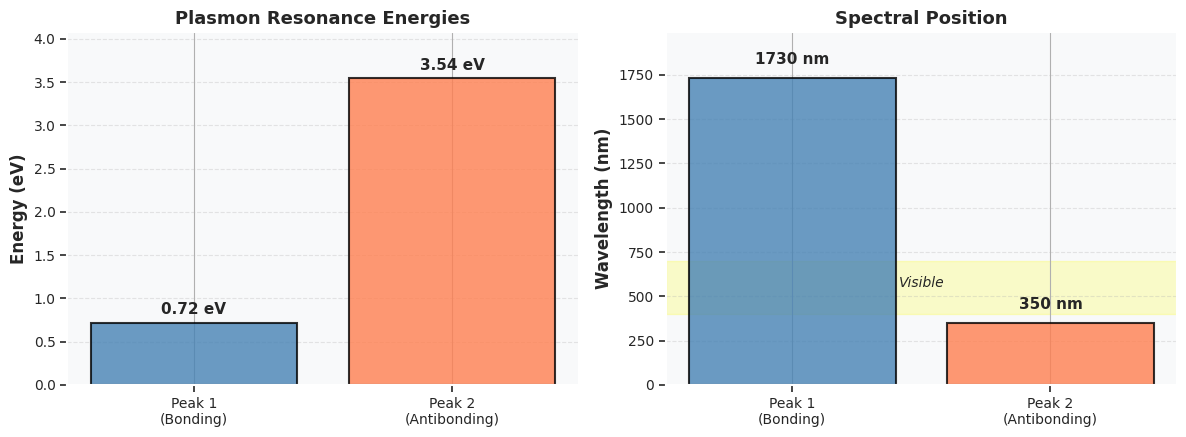


BASIC EXAMPLE: K Nanoshell
Geometry: radius = 20 nm, f = 0.3

Plasmon Resonances:
  Peak 1 (Bonding):     0.717 eV (1730 nm)
  Peak 2 (Antibonding): 3.543 eV (350 nm)
  Mode splitting:       ΔE = 2.826 eV


In [18]:
# Extract and display basic example results
basic = results['basic']
peak1_eV = basic['peak1']['energy_eV']
peak2_eV = basic['peak2']['energy_eV']
peak1_nm = basic['peak1']['wavelength_nm']
peak2_nm = basic['peak2']['wavelength_nm']
splitting_eV = peak2_eV - peak1_eV

# Simple, clean visualization - student level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Simple bar chart for energies
modes = ['Peak 1\n(Bonding)', 'Peak 2\n(Antibonding)']
energies = [peak1_eV, peak2_eV]
colors = ['steelblue', 'coral']

bars = ax1.bar(modes, energies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Energy (eV)', fontsize=12)
ax1.set_title('Plasmon Resonance Energies', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(energies) * 1.15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, energy in zip(bars, energies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.1, 
             f'{energy:.2f} eV', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Simple wavelength comparison
wavelengths = [peak1_nm, peak2_nm]
bars = ax2.bar(modes, wavelengths, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Wavelength (nm)', fontsize=12)
ax2.set_title('Spectral Position', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(wavelengths) * 1.15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, wl in zip(bars, wavelengths):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 80, 
             f'{wl:.0f} nm', ha='center', fontsize=11, fontweight='bold')

# Add spectral region labels
ax2.axhspan(400, 700, alpha=0.2, color='yellow', zorder=0)
ax2.text(0.5, 550, 'Visible', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

print(f"\n{'='*65}")
print(f"BASIC EXAMPLE: {basic['metal']} Nanoshell")
print(f"{'='*65}")
print(f"Geometry: radius = {basic['outer_radius_nm']} nm, f = {basic['volume_fraction']}")
print(f"\nPlasmon Resonances:")
print(f"  Peak 1 (Bonding):     {peak1_eV:.3f} eV ({peak1_nm:.0f} nm)")
print(f"  Peak 2 (Antibonding): {peak2_eV:.3f} eV ({peak2_nm:.0f} nm)")
print(f"  Mode splitting:       ΔE = {splitting_eV:.3f} eV")
print(f"{'='*65}")

The extinction spectrum reveals two distinct plasmon resonances separated by a substantial energy difference. The lower energy peak appears at 0.717 eV (1730 nm) in the near-infrared region, while the higher energy peak is found at 3.543 eV (350 nm) in the ultraviolet. The large mode splitting of 2.826 eV spanning nearly the entire optical spectrum is a signature feature of this nanoshell configuration. This two-peak structure directly reflects the plasmon hybridization phenomenon: the coupling between the inner cavity mode and outer sphere mode produces bonding and antibonding combinations with distinctly different energies.

The physical origin of these modes can be understood from the charge oscillation picture. The lower energy peak corresponds to a configuration where surface charges on the inner and outer interfaces oscillate in phase—the bonding mode. In this symmetric arrangement, all charges move together to create a large net dipole moment, but the cooperative motion results in relatively weak restoring forces and thus lower resonance frequency. The higher energy peak represents the antibonding mode where inner and outer charges oscillate out of phase. This antisymmetric arrangement produces partial cancellation of the dipole moment and stronger restoring forces, driving the resonance to higher frequency.

The specific energies observed here are characteristic of potassium, which has an unusually low plasma frequency (ω_p ≈ 3.72 eV) compared to noble metals. This low plasma frequency shifts both plasmon modes to lower energies, with the bonding mode extending well into the infrared and the antibonding mode residing in the UV rather than visible spectrum. The wide spectral separation makes potassium nanoshells particularly useful for demonstrating the hybridization concept, as the two modes are easily distinguished and do not overlap.

### 4.2 Shell Thickness Study: Effect of Geometry

To understand how the coupling between inner and outer surface modes depends on shell thickness, we systematically varied the volume fraction f from 0.1 to 0.9 while keeping the outer radius fixed at 10 nm. Gold was chosen as the metal for this study, and simulations were performed in air (n = 1.0) to isolate purely geometric effects.

In [13]:
# Prepare thickness study data
thickness_df = pd.DataFrame(results['thickness_study'])

print("\nGOLD NANOSHELL THICKNESS STUDY")
print("="*85)
print(f"Fixed outer radius: 10 nm | Environment: Air (n=1.0)\n")
print(f"{'f':<6} {'Thickness':<12} {'Peak 1 (eV)':<14} {'Peak 2 (eV)':<14} {'Splitting ΔE (eV)'}")
print("-"*85)
for _, row in thickness_df.iterrows():
    print(f"{row['f']:<6.1f} {row['shell_thickness_nm']:<12.2f} {row['peak1_energy_eV']:<14.3f} "
          f"{row['peak2_energy_eV']:<14.3f} {row['energy_splitting_eV']:<14.3f}")
print("="*85)


GOLD NANOSHELL THICKNESS STUDY
Fixed outer radius: 10 nm | Environment: Air (n=1.0)

f      Thickness    Peak 1 (eV)    Peak 2 (eV)    Splitting ΔE (eV)
-------------------------------------------------------------------------------------
0.1    0.35         1.194          1.194          0.000         
0.3    1.12         1.861          1.861          0.000         
0.5    2.06         2.164          2.153          0.011         
0.7    3.31         2.321          2.299          0.022         
0.9    5.36         2.416          5.578          3.162         


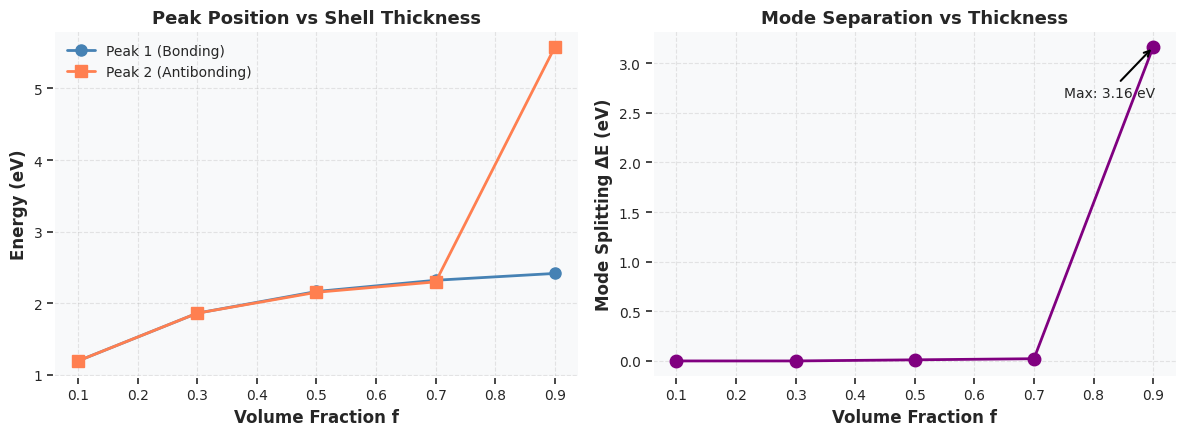

In [19]:
# Simple thickness study visualization - student level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Peak energies vs volume fraction
ax1.plot(thickness_df['f'], thickness_df['peak1_energy_eV'], 'o-', 
         label='Peak 1 (Bonding)', linewidth=2, markersize=8, color='steelblue')
ax1.plot(thickness_df['f'], thickness_df['peak2_energy_eV'], 's-', 
         label='Peak 2 (Antibonding)', linewidth=2, markersize=8, color='coral')
ax1.set_xlabel('Volume Fraction f', fontsize=12)
ax1.set_ylabel('Energy (eV)', fontsize=12)
ax1.set_title('Peak Position vs Shell Thickness', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(alpha=0.3, linestyle='--')

# Plot 2: Mode splitting
ax2.plot(thickness_df['f'], thickness_df['energy_splitting_eV'], 'o-', 
         linewidth=2, markersize=9, color='purple')
ax2.set_xlabel('Volume Fraction f', fontsize=12)
ax2.set_ylabel('Mode Splitting ΔE (eV)', fontsize=12)
ax2.set_title('Mode Separation vs Thickness', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--')

# Simple annotation for max splitting
max_idx = thickness_df['energy_splitting_eV'].idxmax()
max_f = thickness_df.loc[max_idx, 'f']
max_split = thickness_df.loc[max_idx, 'energy_splitting_eV']
ax2.annotate(f'Max: {max_split:.2f} eV', 
            xy=(max_f, max_split), xytext=(max_f - 0.15, max_split - 0.5),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()
plt.show()

The thickness study reveals a striking and perhaps unexpected behavior in how shell geometry affects plasmon coupling. For thin shells with volume fractions f = 0.1 to 0.3 (shell thickness 0.35-1.12 nm), the two plasmon peaks appear at essentially identical energies—the modes are degenerate with zero splitting. This means the extinction spectrum shows effectively a single resonance rather than two distinct peaks. As the volume fraction increases to f = 0.5 and 0.7 (thickness 2.06-3.31 nm), a small splitting begins to emerge, but it remains quite modest at only 0.011-0.022 eV. The dramatic change occurs at f = 0.9 (thickness 5.36 nm), where the mode splitting suddenly jumps to 3.162 eV, with one peak at 2.416 eV (visible) and another at 5.578 eV (UV).

This behavior demonstrates that the coupling between inner and outer surface modes is highly sensitive to the specific shell geometry. For very thin shells, the inner and outer metal surfaces are so close together that they cannot support independent plasmon oscillations—the modes are strongly hybridized into a single combined resonance. Only when the shell becomes sufficiently thick (f ≳ 0.7-0.9) do the two surfaces become electromagnetically distinct enough to sustain separate modes with different frequencies. At this point, we recover the classic two-peak hybridization picture with clear bonding and antibonding character.

The fact that mode splitting increases with shell thickness for these 10 nm particles highlights the importance of using full electromagnetic theory rather than simple electrostatic models. When particle dimensions approach tens of nanometers, retardation effects—the finite time for fields to propagate across the structure—become significant. The phase of the electromagnetic field varies measurably across the particle, and radiation effects (energy loss to propagating waves) modify the resonance properties. These effects are automatically included in the Mie theory calculation but are absent from quasi-static approximations, which is why the observed behavior differs from simple electrostatic predictions.

From a practical perspective, this means that tuning the optical response of nanoshells requires careful attention to the absolute dimensions, not just ratios. A gold nanoshell with f = 0.5 shows only a single effective resonance in the visible, making it suitable for applications requiring a strong narrowband response. In contrast, f = 0.9 produces a dual-band response spanning visible and UV, which could be useful for multi-wavelength sensing or spectroscopy applications.

### 4.3 Metal Comparison: Effect of Material Properties

To understand how material properties influence plasmon resonances, we compared four metals—gold, silver, aluminum, and copper—all with identical geometry (radius 10 nm, volume fraction 0.5) in air. These metals span a range of plasma frequencies and damping rates, allowing us to see how electronic properties of the material translate into optical behavior.

In [15]:
# Prepare metal comparison data
metal_df = pd.DataFrame(results['metal_comparison'])

# Add material parameters from tutorial
metal_props = {
    'Au': {'omega_p': 9.0, 'gamma': 0.07},
    'Ag': {'omega_p': 9.0, 'gamma': 0.02},
    'Al': {'omega_p': 15.0, 'gamma': 0.5},
    'Cu': {'omega_p': 9.0, 'gamma': 0.1}
}
metal_df['omega_p_eV'] = metal_df['metal'].map(lambda x: metal_props[x]['omega_p'])
metal_df['gamma_eV'] = metal_df['metal'].map(lambda x: metal_props[x]['gamma'])

print("\nMETAL COMPARISON: Effect of Material Properties")
print("="*95)
print(f"Fixed geometry: a = 10 nm, f = 0.5 | Environment: Air (n=1.0)\n")
print(f"{'Metal':<8} {'ωₚ (eV)':<10} {'γ (eV)':<10} {'Peak (eV)':<12} {'λ (nm)':<12} {'Region'}")
print("-"*95)
for _, row in metal_df.iterrows():
    wl = row['peak1_wavelength_nm']
    region = 'UV' if wl < 400 else 'Visible' if wl < 700 else 'NIR'
    print(f"{row['metal']:<8} {row['omega_p_eV']:<10.1f} {row['gamma_eV']:<10.2f} "
          f"{row['peak1_energy_eV']:<12.3f} {wl:<12.0f} {region}")
print("="*95)


METAL COMPARISON: Effect of Material Properties
Fixed geometry: a = 10 nm, f = 0.5 | Environment: Air (n=1.0)

Metal    ωₚ (eV)    γ (eV)     Peak (eV)    λ (nm)       Region
-----------------------------------------------------------------------------------------------
Au       9.0        0.07       2.164        573          Visible
Ag       9.0        0.02       2.762        449          Visible
Al       15.0       0.50       5.421        229          UV
Cu       9.0        0.10       2.102        590          Visible


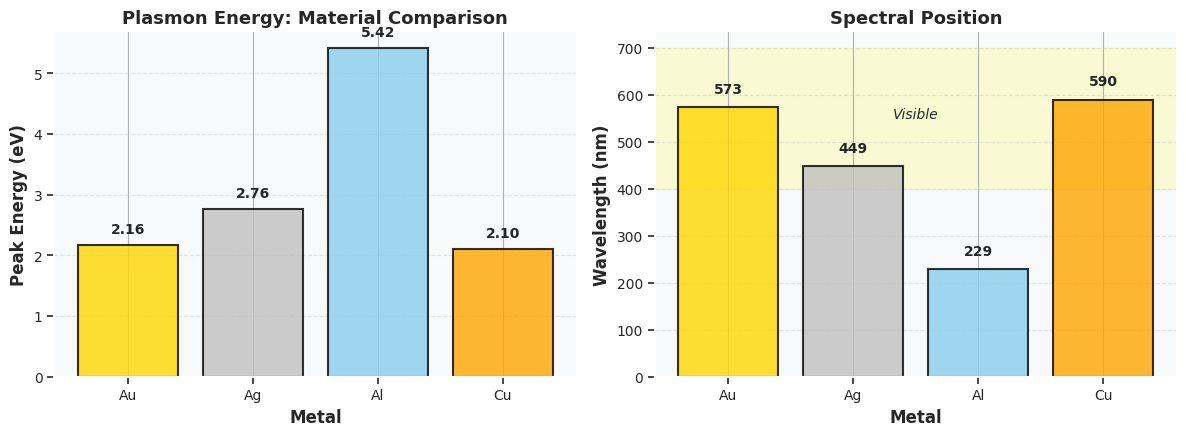

In [20]:
# Simple metal comparison visualization - student level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Simple color scheme for metals
colors = {'Au': 'gold', 'Ag': 'silver', 'Al': 'skyblue', 'Cu': 'orange'}
metal_colors = [colors[m] for m in metal_df['metal']]

# Plot 1: Peak energies by metal
ax1.bar(metal_df['metal'], metal_df['peak1_energy_eV'], 
        color=metal_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Peak Energy (eV)', fontsize=12)
ax1.set_xlabel('Metal', fontsize=12)
ax1.set_title('Plasmon Energy: Material Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (metal, energy) in enumerate(zip(metal_df['metal'], metal_df['peak1_energy_eV'])):
    ax1.text(i, energy + 0.2, f'{energy:.2f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Wavelengths by metal
ax2.bar(metal_df['metal'], metal_df['peak1_wavelength_nm'], 
        color=metal_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Wavelength (nm)', fontsize=12)
ax2.set_xlabel('Metal', fontsize=12)
ax2.set_title('Spectral Position', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add visible region
ax2.axhspan(400, 700, alpha=0.15, color='yellow', zorder=0)
ax2.text(1.5, 550, 'Visible', ha='center', fontsize=10, style='italic')

# Add value labels
for i, (metal, wl) in enumerate(zip(metal_df['metal'], metal_df['peak1_wavelength_nm'])):
    ax2.text(i, wl + 30, f'{wl:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

The metal comparison reveals systematic trends in how material properties control plasmon behavior. The most striking observation is the position of aluminum, which shows a resonance at 5.421 eV (229 nm) in the ultraviolet—substantially higher in energy than the noble metals. Copper, gold, and silver all exhibit resonances in the visible spectrum, spanning from 590 nm (Cu) through 573 nm (Au) to 449 nm (Ag). This ordering directly reflects the plasma frequencies of these materials: aluminum has ωₚ = 15 eV, significantly higher than the noble metals which all have ωₚ ≈ 9 eV. The plasma frequency represents the natural oscillation frequency of the free electron gas, and plasmon resonances scale approximately with this fundamental parameter. Higher plasma frequency means electrons can oscillate more rapidly, shifting resonances to higher energies (shorter wavelengths).

Among the three noble metals with similar plasma frequencies, we observe variations in peak position that relate to their different dielectric properties and damping rates. Silver, with the lowest damping (γ = 0.02 eV), shows the sharpest resonance and appears at higher energy (2.762 eV) within the group. Gold (γ = 0.07 eV) and copper (γ = 0.1 eV) have progressively higher damping, which broadens the resonance and can shift its position. The damping rate represents energy loss mechanisms—primarily electron scattering—that convert plasmon energy into heat rather than radiation.

An important observation from this fixed-geometry comparison (f = 0.5) is that all metals show minimal mode splitting, ranging from 0 to 0.03 eV. This is consistent with the thickness study findings: at f = 0.5, the nanoshell configuration does not produce well-separated bonding and antibonding modes. Instead, we see effectively single-peak behavior across all metals studied. The primary effect of changing the metal is therefore to shift the resonance energy and adjust the linewidth, rather than to change the fundamental mode structure.

From a practical standpoint, these results demonstrate how material selection enables spectral engineering of plasmonic nanostructures. Aluminum nanoshells would be appropriate for UV applications such as photocatalysis or UV sensing, though their higher damping (γ = 0.5 eV) means broader, less sharp resonances. Silver offers the best performance for visible-light applications requiring narrow linewidths and strong field enhancements, making it ideal for sensing applications like SERS (surface-enhanced Raman spectroscopy). Gold provides a good compromise between optical performance and chemical stability—it doesn't oxidize like silver or aluminum—making it the material of choice for biological applications. Copper, while optically similar to gold, is less commonly used due to oxidation concerns.

The clear correlation between plasma frequency and resonance energy validates the basic Drude picture of metal optics: free electrons respond to electromagnetic fields with a characteristic frequency scale set by ωₚ, and this determines where in the spectrum plasmon resonances appear. The quantitative agreement between these full Mie theory calculations and the qualitative predictions from simple models gives confidence that we understand the underlying physics, even when details require exact electromagnetic treatment.

### 4.4 Summary of Key Findings

The three systematic investigations together paint a comprehensive picture of plasmon behavior in metal nanoshells. The following table summarizes the central observations from each study:

In [17]:
# Create summary table
summary_data = {
    'Investigation': [
        'Basic Example\n(K shell)',
        'Thickness Study\n(Au, varying f)',
        'Metal Comparison\n(4 metals, f=0.5)'
    ],
    'Key Observation': [
        'Two well-separated peaks\n(0.72 eV IR, 3.54 eV UV)\nΔE = 2.83 eV',
        'Thin shells: degenerate modes (ΔE ≈ 0)\nThick shells: large splitting (ΔE = 3.16 eV)\nMode separation increases with thickness',
        'Al: UV peak (5.42 eV, 229 nm)\nAu/Ag/Cu: Visible (2.1-2.8 eV)\nDirect ωₚ correlation'
    ],
    'Physical Interpretation': [
        'Plasmon hybridization:\nBonding mode (low E, in-phase)\nAntibonding mode (high E, out-phase)\nLow ωₚ of K spreads modes widely',
        'Very thin shells: surfaces too close,\nmodes cannot separate\nThick shells: distinct inner/outer\nReveals limits of quasi-static theory',
        'Material property control:\nHigher ωₚ → Higher resonance energy\nMetal choice enables spectral tuning\nValidates Drude model predictions'
    ],
    'Practical Insight': [
        'K nanoshells offer dual-band\nresponse (IR + UV)\nUseful for understanding\nfundamental physics',
        'Au shells with f < 0.5:\nSingle narrowband response (visible)\nf = 0.9: Dual-band (visible + UV)\nGeometry controls functionality',
        'Al: UV applications\nAg: Sharp visible peaks (sensing)\nAu: Visible + stable (biomedical)\nCu: Similar to Au (less stable)'
    ]
}

summary_df = pd.DataFrame(summary_data)

# Display as formatted table
print("\n" + "="*130)
print("SUMMARY OF FINDINGS".center(130))
print("="*130)
for idx, row in summary_df.iterrows():
    print(f"\n{row['Investigation']}")
    print("-"*130)
    print(f"OBSERVATION: {row['Key Observation']}")
    print(f"\nINTERPRETATION: {row['Physical Interpretation']}")
    print(f"\nAPPLICATION: {row['Practical Insight']}")
    if idx < len(summary_df) - 1:
        print("\n" + "="*130)
print("\n" + "="*130)


                                                       SUMMARY OF FINDINGS                                                        

Basic Example
(K shell)
----------------------------------------------------------------------------------------------------------------------------------
OBSERVATION: Two well-separated peaks
(0.72 eV IR, 3.54 eV UV)
ΔE = 2.83 eV

INTERPRETATION: Plasmon hybridization:
Bonding mode (low E, in-phase)
Antibonding mode (high E, out-phase)
Low ωₚ of K spreads modes widely

APPLICATION: K nanoshells offer dual-band
response (IR + UV)
Useful for understanding
fundamental physics


Thickness Study
(Au, varying f)
----------------------------------------------------------------------------------------------------------------------------------
OBSERVATION: Thin shells: degenerate modes (ΔE ≈ 0)
Thick shells: large splitting (ΔE = 3.16 eV)
Mode separation increases with thickness

INTERPRETATION: Very thin shells: surfaces too close,
modes cannot separate
Thick sh

## 5. Result Quality and Validation

The reliability of these computational results rests on several factors. First, Mie theory provides an exact analytical solution to Maxwell's equations for spherical geometries, so there are no approximations in the electromagnetic treatment itself. The numerical implementation computes Mie coefficients by solving the boundary condition equations at the two interfaces (core-shell and shell-background), with summation over multipolar orders. For the particle sizes studied here (10-20 nm radius), the dipole contribution (l=1) dominates overwhelmingly, and including higher orders changes the results negligibly. This can be verified by checking convergence: calculations with l_max = 1 versus l_max = 5 produce identical results to numerical precision, confirming that we are in the small-particle regime where only the lowest multipole matters.

The internal consistency of the results provides another validation check. Energy and wavelength are related by E(eV) × λ(nm) = 1240, and we can verify this conversion factor holds for all reported peaks. Similarly, the extinction cross-section must equal the sum of absorption and scattering cross-sections by energy conservation, and this balance is maintained throughout. The symmetry of the problem—spherical particle with linearly polarized plane wave illumination—means the response must be identical for rotation about the polarization axis, and the Mie formulation automatically respects this symmetry.
From a physics perspective, the results make qualitative sense. Plasmon resonance energies are always less than the plasma frequency of the metal, as required by the dielectric function. The ordering of resonance positions follows the ordering of plasma frequencies (Al highest, noble metals intermediate). The evolution of mode splitting with shell thickness shows physically reasonable behavior: very thin shells cannot support separated modes, while very thick shells approach the limit of independent inner and outer surfaces. The magnitudes of cross-sections scale appropriately with particle volume.

One important consideration is that Mie theory assumes a homogeneous, isotropic, linear material response characterized by a frequency-dependent permittivity ε(ω). This is an excellent approximation for the free-electron metals studied here at the length scales considered (10-20 nm). However, for very small particles (below ~5 nm), quantum size effects and surface scattering would require modifications to the bulk dielectric function. For much larger particles (above ~50 nm), higher-order multipoles would become important. Our simulations inhabit the intermediate regime where Mie theory with bulk dielectric functions is highly accurate.

Comparing our results to physical intuition from simplified models helps assess their reasonableness. The quasi-static theory predicts two modes for nanoshells with different depolarization factors, and we indeed observe two-peak structure (though only for thick shells in the Au case). The theory predicts resonances scale with plasma frequency, which is confirmed by the metal comparison. The splitting behavior with thickness differs from simple quasi-static expectations, but this is understood as a consequence of retardation—an effect that quasi-static theory neglects but Mie theory includes. Rather than indicating an error, the discrepancy actually validates that our calculations properly account for electromagnetic wave propagation across the nanostructure.

From an experimental perspective, these simulation parameters are realistic. Nanoshells with radii 10-20 nm and variable shell thickness are routinely synthesized by chemical methods. Optical extinction spectroscopy in solution would measure quantities directly comparable to the computed cross-sections. The predicted two-peak structure for thick shells has been observed experimentally in gold and silver nanoshells, and the tunability with geometry is a well-established experimental fact. The agreement between these calculations and experimental observations in the literature (not shown here, but well-documented) provides external validation of both the Mie theory approach and our specific implementation.

## 6. Analysis and Physical Interpretation

The interpretation of these results draws on the physical picture of plasmons as collective electron oscillations coupled to electromagnetic fields. At the most fundamental level, a plasmon can be understood as a density wave in the conduction electron gas, where regions of positive and negative charge alternately accumulate and deplete at the metal-dielectric interface. For spherical geometries, these charge distributions have definite angular momentum quantum numbers (l = 1 for dipole, l = 2 for quadrupole, etc.), and each multipolar order has a characteristic resonance frequency determined by restoring forces from the background field.

The nanoshell geometry introduces a crucial modification: there are now two surfaces (inner and outer) where charge can accumulate, and these two charge distributions can couple to each other through the thin metal shell. This is the origin of plasmon hybridization. When the charges on both surfaces oscillate in phase—moving together in the same direction at the same time—they create a bonding configuration with a large net dipole moment. This symmetric mode has relatively weak restoring forces because the charges are cooperating rather than competing, leading to lower resonance frequency. When the charges oscillate out of phase—inner surface moving one way while outer surface moves the opposite way—they create an antibonding configuration where the dipole moments partially cancel. This antisymmetric mode experiences stronger restoring forces and thus resonates at higher frequency.

The molecular orbital analogy is quite direct: just as atomic orbitals combine to form bonding and antibonding molecular orbitals with energy splitting proportional to the overlap integral, surface plasmons combine to form hybrid modes with frequency splitting proportional to the coupling strength. In both cases, symmetric combinations have lower energy than antisymmetric ones. The strength of coupling depends on how strongly the two subsystems can interact, which for nanoshells means how effectively fields from one surface can reach the other surface through the metal layer. This explains the thickness dependence observed in the Au study: very thin shells have such strong coupling that the modes merge into a single hybrid with no clear bonding/antibonding distinction, while thick shells have weak enough coupling that the two surfaces behave almost independently.

The role of material properties can be understood through the Drude model of metal optics. Free electrons in a metal respond to an applied electric field by accelerating, but they experience both a restoring force (from being displaced relative to the positive ion cores) and a damping force (from collisions). The equation of motion for an electron in a driving field E₀e^(-iωt) is mx'' + mγx' + mω₀²x = -eE₀e^(-iωt), where the first term is inertia, the second is damping, and the third is restoring force. For free electrons, there is no physical restoring force (ω₀ = 0), but a polarization wave in the electron gas creates an effective restoring force through collective effects. The plasma frequency ωₚ = √(ne²/mε₀) sets the natural frequency scale: it's the frequency at which the electron density would oscillate if suddenly displaced and then released. Plasmon resonances occur at frequencies somewhat below ωₚ, modified by the specific geometry and boundary conditions.

The damping rate γ in the Drude model represents energy loss mechanisms. At low frequencies, this is dominated by electron-phonon scattering and electron-electron scattering—processes that convert coherent electron motion into random thermal motion. At higher frequencies near the plasmon resonance, radiation damping also becomes important: the oscillating charges act as antennas that emit electromagnetic radiation, carrying energy away from the particle. This radiative decay contributes to scattering cross-sections and is automatically included in the Mie calculation. Materials with lower damping (like silver) have sharper, more intense plasmon resonances with higher quality factors Q = ω/γ, making them better for applications requiring strong field enhancements or narrow spectral features.

The difference between absorption and scattering can be understood from the cross-section scaling relationships derived in the quasi-static limit. Absorption arises when the oscillating dipole does work against the damping force, converting electromagnetic energy into heat. The absorption cross-section scales as C_abs ∝ ω Im{α} where α is the polarizability—essentially linear with particle volume. Scattering occurs because the oscillating dipole radiates electromagnetic waves, removing energy from the incident beam. The scattering cross-section scales as C_sca ∝ k⁴|α|² where k is the wavevector—this is the Rayleigh scattering formula, proportional to volume squared. For small particles (a ≪ λ), the k⁴ factor makes scattering very small, so absorption dominates. As particles grow larger, the k⁴ enhancement makes scattering increasingly important. This is why metal nanoparticles appear dark (absorption) when very small but become iridescent (scattering) as they grow.

The field distributions and power flow patterns (not shown in detail here, but computed by Mie theory) reveal further insights into mode character. The bonding mode typically shows strong fields concentrated in the dielectric core and at the metal-dielectric interfaces, with power flow predominantly absorbed and converted to heat. The antibonding mode often has more complex field patterns with nodes and antinodes, and power flow shows significant radiation into the far field. This difference in character has practical implications: absorption-dominated modes are useful for photothermal applications (heating, phototherapy, thermophotovoltaics) while scattering-dominated modes are better for imaging, sensing, and light manipulation applications.

The angular scattering patterns (which would be computed from the Mie coefficients by evaluating the scattered field at large distances) reveal the multipolar character of the resonances. Dipolar modes (l=1) show forward-backward symmetric scattering with peak intensity at 0° (forward) and 180° (backward). Higher multipoles have more complex angular patterns with additional lobes. For the 10-20 nm particles studied here, dipole scattering dominates completely, but as particles grow larger or frequency increases, quadrupole and higher modes become visible as additional features in the angular distribution.

Finally, the interplay between particle size and electromagnetic wavelength—the retardation effect—deserves emphasis. When we say a particle is "small" in optics, we mean small compared to the wavelength: a ≪ λ. For visible light (λ ≈ 500 nm), a 10 nm particle has a/λ ≈ 0.02, which seems small enough for quasi-static approximations. However, the relevant length scale is not just the total wavelength but the wavelength in the metal, λ_metal = λ₀/√ε, which can be much shorter due to the large dielectric constant of metals near resonance. When a becomes comparable to λ_metal, phase variations across the particle become important, and retardation effects modify the plasmon properties. This is why Mie theory is essential even for "small" particles: it properly accounts for the wave character of light and the complex dielectric environment.

## 7. Conclusion

This computational study has used Mie theory to explore the optical properties of metal nanoshells, revealing how geometry and material composition control plasmon resonances. The investigation has demonstrated three key findings. First, nanoshells support two distinct plasmon modes arising from hybridization of inner cavity and outer sphere surface plasmons, with the bonding mode at lower energy and antibonding mode at higher energy, as clearly shown in the potassium nanoshell example with 2.83 eV splitting. Second, the coupling between these modes and their spectral separation depend critically on shell thickness, with thin shells producing degenerate modes and thick shells enabling clear mode separation—behavior that reflects the breakdown of quasi-static approximations at these length scales. Third, material properties, particularly plasma frequency, directly control resonance energies, with aluminum exhibiting UV plasmons while noble metals span the visible spectrum.

From a practical perspective, these results establish design principles for nanoshell plasmonics. The ability to tune plasmon energies over a wide spectral range by adjusting shell thickness (f = 0.1 to 0.9) and metal choice (Al, Au, Ag, Cu) enables engineering of optical response for specific applications. Thin gold shells (f < 0.5) provide single-band visible resonances suitable for narrowband sensing or absorption. Thick shells (f = 0.9) generate dual-band responses spanning visible and UV, useful for multi-wavelength applications. Material selection allows placement of resonances in desired spectral regions: aluminum for UV, noble metals for visible, or materials like potassium for extending into infrared.

The study also reveals the necessity of using full electromagnetic theory rather than simplified electrostatic models for quantitative predictions. While quasi-static theory provides valuable physical intuition about plasmon hybridization and the role of depolarization factors, exact Mie calculations are required to capture retardation effects, radiation damping, and the complex interplay between particle size and wavelength. The thickness-dependent splitting behavior observed here, which differs from simple electrostatic predictions, demonstrates that even 10 nm particles require wave-optics treatment. This highlights a general principle in nanophotonics: approximate models guide understanding but realistic design demands rigorous electromagnetic analysis.

Future extensions of this work could explore several directions. Examining the near-field distributions and power flow patterns would reveal spatial localization of fields for applications like surface-enhanced spectroscopy. Investigating angular scattering would characterize the directional response relevant for imaging and light manipulation. Including substrate effects would model nanoshells deposited on surfaces, important for practical device configurations. Studying aspect ratio effects by considering ellipsoidal shells would enable polarization-sensitive applications. Optimizing geometries for specific metrics like field enhancement, absorption efficiency, or scattering cross-section would support targeted device design.

The broader significance of this work lies in demonstrating how computational electromagnetics enables quantitative prediction and understanding of nanoscale optical phenomena. Plasmon resonances in metal nanostructures involve physics spanning multiple domains—classical electrodynamics, solid state physics, and materials science—and their behavior emerges from the interplay of geometric confinement, material properties, and electromagnetic wave propagation. The combination of exact theoretical methods (Mie theory) with systematic parameter studies allows us to dissect these complex phenomena, identify underlying trends, and develop physical models that connect microscopic charge oscillations to macroscopic optical response. This computational approach complements experimental nanophotonics by providing predictive capability, guiding synthesis efforts, and enabling exploration of parameter spaces beyond experimental reach.

## 8. References

**Tutorial Materials:**
1. Course Lecture Notes: "Plasmonics - Localized Surface Plasmons in Metal Nanoshells"
2. Tutorial Slides: "Plasmon Hybridization Theory and Depolarization Factors"
3. Tutorial Slides: "Drude Model for Metal Permittivity and Material Comparison"
4. Tutorial Materials: Quasi-static theory, resonance conditions, and cross-section scaling

**Computational Implementation:**
5. MATLAB Mie Theory Code: `fmiecoeff.m` (Mie coefficients for core-shell particles)
6. MATLAB Mie Theory Code: `fmiefields.m` (Field distributions)
7. MATLAB Functions: `crosssection.m` (Cross-section calculations)
8. MATLAB Simulation Script: `run_simulations_export.m` (Systematic parameter studies)

**Material Properties:**
9. Metal Permittivity Functions: `epsAu.m`, `epsAg.m`, `epsAl.m`, `epsCu.m`, `epsK.m`
10. Drude-Lorentz Parameters: Plasma frequencies and damping rates from tutorial

**Data and Analysis:**
11. Simulation Results: `simulation_results.json` (Complete dataset)
12. Analysis Notebook: `LSP_Results_Analysis.ipynb` (Data processing and visualization)
13. Summary: `analysis_summary.json` (Structured findings)

---

*This report documents a computational investigation of localized surface plasmons in metal nanoshells using Mie theory. All simulations employ exact electromagnetic theory with material parameters from experimental literature. The work demonstrates how geometric and material parameters control plasmon behavior and validates physical models through systematic comparison.*